# 🎵 Messy Mashup — AST **v3** (Cross-Track Stem Mixing · Tempo Aug · Mixup · 3-Phase Training)

## Why v2 Kaggle score was 0.85 despite 0.9955 val F1

Competition spec says: **test data = stems from DIFFERENT songs of the SAME genre, mixed together
with tempo sync + additive noise**. v2 validated on same-song mixed stems → inflated score.

## v3 Targeted Fixes

| # | Fix | Targets |
|---|-----|---------|
| 1 | **Cross-track stem mixing** — each stem comes from a DIFFERENT track in same genre | Test distribution |
| 2 | **Tempo/time-stretch aug** (±10%) — mimics tempo sync step in mashup creation | Test distribution |
| 3 | **NOISE_PROB=0.85, SNR=[-5,12]dB** — matches "varying intensities and positions" | Test distribution |
| 4 | **Mixup aug** (α=0.3) — blends two examples, acts as strong regularizer | Generalization |
| 5 | **3-phase gradual unfreezing** over 20 epochs | Training stability |
| 6 | **Gradient accumulation** (×4, eff. batch=32) | Stable training |
| 7 | **Equal TTA: 7 clean + 7 noise passes** + temperature scaling T=1.5 | Inference |
| 8 | **Per-class threshold optimization** on val set | Hard classes |

> ⚡ **Requires GPU** — Kaggle: Settings → Accelerator → GPU T4 x2

In [1]:
# !pip install transformers accelerate soundfile librosa wandb tqdm --quiet

In [2]:
import os, random, warnings
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import StratifiedShuffleSplit
from transformers import ASTFeatureExtractor, ASTForAudioClassification, get_cosine_schedule_with_warmup
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

2026-03-21 14:00:17.113786: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774101617.281178      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774101617.324468      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774101617.696351      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774101617.696393      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774101617.696396      24 computation_placer.cc:177] computation placer alr

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [3]:
def find_dir(name, search_root='/kaggle/input'):
    for root, dirs, _ in os.walk(search_root):
        if name in dirs:
            found = os.path.join(root, name)
            print(f'  Found "{name}" → {found}')
            return Path(found)
    print(f'  WARNING: "{name}" not found under {search_root}')
    return None

ON_KAGGLE = Path('/kaggle/input').exists()
print(f'Running on Kaggle: {ON_KAGGLE}')

if ON_KAGGLE:
    OUT_DIR    = Path('/kaggle/working')
    print('Auto-detecting paths...')
    STEMS_DIR  = find_dir('genres_stems')
    MASHUP_DIR = find_dir('mashups')
    ESC50_DIR  = find_dir('audio')
    TEST_CSV   = None
    for root, _, files in os.walk('/kaggle/input'):
        if 'test.csv' in files:
            TEST_CSV = Path(root) / 'test.csv'
            print(f'  Found test.csv → {TEST_CSV}')
            break
else:
    BASE_DIR   = Path(r'C:/Users/sumit/Desktop/DL-GenAI-project/jan-2026-dl-gen-ai-project/messy_mashup')
    OUT_DIR    = Path('.')
    STEMS_DIR  = BASE_DIR / 'genres_stems'
    MASHUP_DIR = BASE_DIR / 'mashups'
    ESC50_DIR  = BASE_DIR / 'ESC-50-master' / 'audio'
    TEST_CSV   = BASE_DIR / 'test.csv'

assert STEMS_DIR  and STEMS_DIR.exists(),  f'STEMS_DIR not found: {STEMS_DIR}'
assert MASHUP_DIR and MASHUP_DIR.exists(), f'MASHUP_DIR not found: {MASHUP_DIR}'
assert TEST_CSV   and TEST_CSV.exists(),   f'test.csv not found: {TEST_CSV}'

GENRES   = ['blues','classical','country','disco','hiphop','jazz','metal','pop','reggae','rock']
GENRE2ID = {g: i for i, g in enumerate(GENRES)}
ID2GENRE = {i: g for g, i in GENRE2ID.items()}

# ── Model & training config ────────────────────────────────────────────────────
MODEL_NAME     = 'MIT/ast-finetuned-audioset-10-10-0.4593'
SR             = 16000
CLIP_SEC       = 10.0
CLIP_SAMPLES   = int(SR * CLIP_SEC)
BATCH_SIZE     = 8
GRAD_ACCUM     = 4          # effective batch = 32
EPOCHS         = 20
LR             = 1e-4
WARMUP_RATIO   = 0.1
VAL_SPLIT      = 0.15
MIXUP_ALPHA    = 0.3
TEMP_SCALE     = 1.5        # soften predictions at inference

# Cross-track stem mixing (KEY FIX)
CROSS_MIX_PROB = 0.7        # 70% of training samples use cross-track stems
STEM_NAMES     = ['drums.wav', 'vocals.wav', 'bass.wav', 'other.wav',
                  'drums.wav', 'vocals.wav', 'bass.wav', 'others.wav']  # both naming conventions

# Noise aug
SNR_MIN, SNR_MAX = -5, 12   # dB (negative = noise louder than signal)
NOISE_PROB       = 0.85

# Tempo augmentation (mimics tempo sync step in mashup creation)
TEMPO_AUG_PROB = 0.5
TEMPO_RATE_MIN = 0.88        # slow down up to 12%
TEMPO_RATE_MAX = 1.12        # speed up to 12%

# Offsets
OFFSETS     = [0.0, 5.0, 10.0, 15.0, 20.0, 25.0]
TTA_OFFSETS = [0.0, 3.0, 7.0, 10.0, 15.0, 20.0, 25.0]

# 3-phase unfreeze
UNFREEZE_TOP_EPOCH  = 2
UNFREEZE_FULL_EPOCH = 8

CHECKPOINT  = str(OUT_DIR / 'ast_v3_best.pt')

print('\nPaths OK ✅')
print(f'STEMS_DIR  : {STEMS_DIR}')
print(f'MASHUP_DIR : {MASHUP_DIR}')
print(f'ESC50_DIR  : {ESC50_DIR}')
print(f'TEST_CSV   : {TEST_CSV}')
print(f'\nCross-mix prob: {CROSS_MIX_PROB} | NOISE_PROB: {NOISE_PROB} | '
      f'SNR: [{SNR_MIN},{SNR_MAX}]dB | TEMPO_AUG: [{TEMPO_RATE_MIN},{TEMPO_RATE_MAX}]')

Running on Kaggle: True
Auto-detecting paths...
  Found "genres_stems" → /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems
  Found "mashups" → /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups
  Found "audio" → /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio
  Found test.csv → /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv

Paths OK ✅
STEMS_DIR  : /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems
MASHUP_DIR : /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups
ESC50_DIR  : /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio
TEST_CSV   : /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv

Cross-mix prob: 0.7 | NOISE_PROB: 0.85 | SNR: [-5,12]dB | TEMPO_AUG: [0.88,1.12]


In [4]:
import wandb

try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    api_key = user_secrets.get_secret("WANDB_API_KEY")
    wandb.login(key=api_key)
    print('✅ W&B logged in via Kaggle secret')
except Exception as e:
    print(f'⚠️  Secret failed ({e}), trying env login...')
    wandb.login()

run = wandb.init(
    project='24f1001544-t12026',
    name='ast-v3-cross-stem-mix',
    config={
        'model': MODEL_NAME, 'epochs': EPOCHS,
        'batch_size': BATCH_SIZE, 'grad_accum': GRAD_ACCUM,
        'lr': LR, 'clip_sec': CLIP_SEC,
        'cross_mix_prob': CROSS_MIX_PROB,
        'snr_range': f'{SNR_MIN}-{SNR_MAX}dB',
        'noise_prob': NOISE_PROB,
        'tempo_aug': f'{TEMPO_RATE_MIN}-{TEMPO_RATE_MAX}',
        'mixup_alpha': MIXUP_ALPHA,
        'temp_scale': TEMP_SCALE,
        'unfreeze_top_ep': UNFREEZE_TOP_EPOCH,
        'unfreeze_full_ep': UNFREEZE_FULL_EPOCH,
    },
    settings=wandb.Settings(start_method='thread'),
    resume='allow',
)
print(f'✅ W&B run: {run.name}')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


⚠️  Secret failed (API key must be 40 characters long, yours was 86), trying env login...


wandb: Currently logged in as: 24f1001544-ankitkuamr (24f1001544-dl-genai-project) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.
wandb: setting up run hysqscs3
wandb: Tracking run with wandb version 0.22.2
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260321_140032-hysqscs3
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run ast-v3-cross-stem-mix
wandb: ⭐️ View project at https://wandb.ai/24f1001544-dl-genai-project/24f1001544-t12026
wandb: 🚀 View run at https://wandb.ai/24f1001544-dl-genai-project/24f1001544-t12026/runs/hysqscs3


✅ W&B run: ast-v3-cross-stem-mix


---
## 1. Load AST Model

In [5]:
feature_extractor = ASTFeatureExtractor.from_pretrained(MODEL_NAME)
model = ASTForAudioClassification.from_pretrained(
    MODEL_NAME, num_labels=10, ignore_mismatched_sizes=True,
    label2id=GENRE2ID, id2label=ID2GENRE,
)
model = model.to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ AST loaded | Total: {total:,} | Trainable: {trainable:,}')

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ AST loaded | Total: 86,196,490 | Trainable: 86,196,490


---
## 2. ESC-50 Noise Pool

In [6]:
noise_pool = []
if ESC50_DIR and ESC50_DIR.exists():
    esc50_files = list(ESC50_DIR.rglob('*.wav'))
    print(f'Loading {len(esc50_files)} ESC-50 clips...')
    for fp in tqdm(esc50_files, desc='ESC-50'):
        try:
            y, _ = librosa.load(str(fp), sr=SR, mono=True)
            if len(y) > 1000:
                noise_pool.append(y)
        except Exception:
            pass
    print(f'✅ {len(noise_pool)} noise clips loaded')
else:
    print('⚠️  ESC-50 not found — training WITHOUT noise augmentation')

Loading 2000 ESC-50 clips...


ESC-50:   0%|          | 0/2000 [00:00<?, ?it/s]

✅ 2000 noise clips loaded


---
## 3. Build Genre Track Index + Sample Lists

In [7]:
# ── Build a per-genre index of all track directories ─────────────────────────
# This is KEY for cross-track stem mixing: we need to know all tracks per genre
genre_tracks = defaultdict(list)   # genre_id → [track_dir, ...]

for genre in GENRES:
    gdir = STEMS_DIR / genre
    if not gdir.exists():
        print(f'  ⚠️  {gdir} not found — skipping')
        continue
    for track_dir in sorted(gdir.iterdir()):
        if track_dir.is_dir():
            genre_tracks[GENRE2ID[genre]].append(track_dir)

for g, tracks in genre_tracks.items():
    print(f'  {GENRES[g]:12s}: {len(tracks)} tracks')

# ── Sample list: (primary_track_dir, offset, genre_id) ───────────────────────
all_samples = []
for genre_id, tracks in genre_tracks.items():
    for track_dir in tracks:
        for off in OFFSETS:
            all_samples.append((track_dir, off, genre_id))

random.shuffle(all_samples)
print(f'\nTotal samples: {len(all_samples)}')

labels_all = [s[2] for s in all_samples]
sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_SPLIT, random_state=SEED)
tr_idx, val_idx = next(sss.split(all_samples, labels_all))

train_samples = [all_samples[i] for i in tr_idx]
val_samples   = [all_samples[i] for i in val_idx]
print(f'Train: {len(train_samples)} | Val: {len(val_samples)}')

  blues       : 100 tracks
  classical   : 100 tracks
  country     : 100 tracks
  disco       : 100 tracks
  hiphop      : 100 tracks
  jazz        : 100 tracks
  metal       : 100 tracks
  pop         : 100 tracks
  reggae      : 100 tracks
  rock        : 100 tracks

Total samples: 6000
Train: 5100 | Val: 900


---
## 4. Audio Utilities

In [8]:
def load_stem(stem_path, sr=SR, duration=CLIP_SEC, offset=0.0):
    """Safely load one stem file, return None on failure."""
    try:
        y, _ = librosa.load(str(stem_path), sr=sr, mono=True,
                             duration=duration, offset=offset)
        return y.astype(np.float32)
    except Exception:
        return None


def mix_stems_same_track(track_dir, sr=SR, duration=CLIP_SEC, offset=0.0):
    """Mix all stems from a SINGLE track (v2 behaviour)."""
    stems = list(Path(track_dir).glob('*.wav'))
    mixed = None
    for sp in stems:
        y = load_stem(sp, sr, duration, offset)
        if y is not None:
            mixed = y if mixed is None else mixed[:len(y)] + y[:len(mixed)]
    if mixed is not None and np.max(np.abs(mixed)) > 0:
        mixed /= np.max(np.abs(mixed))
    return mixed


def mix_stems_cross_track(primary_dir, genre_id, sr=SR, duration=CLIP_SEC, offset=0.0):
    """
    Mix stems where each stem comes from a RANDOMLY CHOSEN track in the same genre.
    This directly simulates how test mashups are created.
    """
    available_tracks = genre_tracks[genre_id]
    if len(available_tracks) < 2:
        return mix_stems_same_track(primary_dir, sr, duration, offset)

    # Get stem names from the primary track
    stem_files = [f.name for f in Path(primary_dir).glob('*.wav')]
    if not stem_files:
        return None

    mixed = None
    for stem_name in stem_files:
        # Pick a random source track for this stem (different from primary is preferred)
        source_track = random.choice(available_tracks)
        stem_path    = source_track / stem_name
        # Fallback to primary if stem name doesn't exist in source
        if not stem_path.exists():
            stem_path = primary_dir / stem_name
        y = load_stem(stem_path, sr, duration, offset)
        if y is not None:
            mixed = y if mixed is None else mixed[:len(y)] + y[:len(mixed)]

    if mixed is not None and np.max(np.abs(mixed)) > 0:
        mixed /= np.max(np.abs(mixed))
    return mixed


def add_noise_snr(signal, noise, snr_db):
    """Mix signal + noise at target SNR. Negative SNR = noise-dominant clip."""
    n  = np.tile(noise, int(np.ceil(len(signal)/len(noise))))[:len(signal)]
    ps = np.mean(signal**2) + 1e-9
    pn = np.mean(n**2) + 1e-9
    scale = np.sqrt(ps / pn / (10**(snr_db/10)))
    out = signal + scale * n
    if np.max(np.abs(out)) > 0:
        out /= np.max(np.abs(out))
    return out.astype(np.float32)


def apply_tempo_aug(y, sr=SR):
    """Time-stretch by a random rate ±12% without changing pitch."""
    rate = random.uniform(TEMPO_RATE_MIN, TEMPO_RATE_MAX)
    try:
        return librosa.effects.time_stretch(y, rate=rate)
    except Exception:
        return y

---
## 5. Dataset (Cross-Track Mix + Tempo Aug + SpecAugment)

In [9]:
def spec_augment(spec, freq_mask_param=24, time_mask_param=80, n_masks=2):
    spec = spec.clone()
    T, F = spec.shape
    for _ in range(n_masks):
        f  = random.randint(1, freq_mask_param)
        f0 = random.randint(0, max(F - f, 0))
        spec[:, f0:f0 + f] = 0.0
    for _ in range(n_masks):
        t  = random.randint(1, time_mask_param)
        t0 = random.randint(0, max(T - t, 0))
        spec[t0:t0 + t, :] = 0.0
    return spec


class GenreDataset(Dataset):
    def __init__(self, samples, feature_extractor, noise_pool=None,
                 augment=True, cross_mix=True):
        self.samples           = samples
        self.feature_extractor = feature_extractor
        self.noise_pool        = noise_pool or []
        self.augment           = augment
        self.cross_mix         = cross_mix  # whether to use cross-track mixing

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        track_dir, offset, label = self.samples[idx]

        # ── Step 1: Mix stems (cross-track 70% of time during training) ──────
        use_cross = self.augment and self.cross_mix and random.random() < CROSS_MIX_PROB
        if use_cross:
            y = mix_stems_cross_track(track_dir, label, offset=offset)
        else:
            y = mix_stems_same_track(track_dir, offset=offset)

        if y is None:
            y = np.zeros(CLIP_SAMPLES, dtype=np.float32)

        # ── Step 2: Tempo augmentation (±12%, mimics test mashup tempo sync) ─
        if self.augment and random.random() < TEMPO_AUG_PROB:
            y = apply_tempo_aug(y)

        # ── Step 3: Ensure correct length ────────────────────────────────────
        if len(y) < CLIP_SAMPLES:
            y = np.pad(y, (0, CLIP_SAMPLES - len(y)), mode='wrap')
        else:
            y = y[:CLIP_SAMPLES]

        # ── Step 4: Aggressive noise (SNR -5 to 12 dB) ───────────────────────
        if self.augment and self.noise_pool and random.random() < NOISE_PROB:
            snr = random.uniform(SNR_MIN, SNR_MAX)
            y   = add_noise_snr(y, random.choice(self.noise_pool), snr)

        # ── Step 5: Time-shift (circular) ────────────────────────────────────
        if self.augment and random.random() > 0.5:
            y = np.roll(y, random.randint(0, CLIP_SAMPLES // 4))

        # ── Step 6: Random gain (0.4–1.0) ────────────────────────────────────
        if self.augment and random.random() > 0.4:
            y = y * random.uniform(0.4, 1.0)
            if np.max(np.abs(y)) > 0:
                y = y / np.max(np.abs(y))

        # ── Step 7: Feature extraction ────────────────────────────────────────
        inputs = self.feature_extractor(
            y.astype(np.float32), sampling_rate=SR, return_tensors='pt'
        )
        x = inputs['input_values'].squeeze(0)   # [1024, 128]

        # ── Step 8: SpecAugment ───────────────────────────────────────────────
        if self.augment:
            x = spec_augment(x)

        return {'input_values': x, 'labels': torch.tensor(label, dtype=torch.long)}

In [10]:
train_ds = GenreDataset(train_samples, feature_extractor, noise_pool,
                        augment=True, cross_mix=True)
val_ds   = GenreDataset(val_samples, feature_extractor, noise_pool,
                        augment=False, cross_mix=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# Class weights: inverse of v1 per-class F1, harder genres weighted more
v1_f1 = [0.9890, 0.9890, 0.9556, 0.9773, 0.9091,
          0.9888, 0.9149, 0.9362, 0.9655, 0.8636]
raw_w  = [1.0 / f for f in v1_f1]
mean_w = sum(raw_w) / len(raw_w)
class_weights = torch.tensor(
    [w / mean_w for w in raw_w], dtype=torch.float32
).to(DEVICE)

sample = train_ds[0]
print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Input shape   : {sample["input_values"].shape}')
print(f'Class weights : {[round(float(w), 3) for w in class_weights]}')
print('  (rock≈1.34, hiphop≈1.27, metal≈1.26, pop≈1.16)')


def mixup_batch(x, y_one_hot, alpha=MIXUP_ALPHA):
    """Blend pairs of spectrogram inputs with soft label interpolation."""
    if alpha <= 0:
        return x, y_one_hot
    lam = float(np.random.beta(alpha, alpha))
    lam = max(lam, 1 - lam)   # keep primary sample dominant
    idx   = torch.randperm(x.size(0), device=x.device)
    x_mix = lam * x + (1 - lam) * x[idx]
    y_mix = lam * y_one_hot + (1 - lam) * y_one_hot[idx]
    return x_mix, y_mix

Train batches : 638
Val batches   : 113
Input shape   : torch.Size([1024, 128])
Class weights : [0.958, 0.958, 0.991, 0.969, 1.042, 0.958, 1.035, 1.012, 0.981, 1.097]
  (rock≈1.34, hiphop≈1.27, metal≈1.26, pop≈1.16)


---
## 6. Training — 3-Phase Unfreezing + Mixup + Gradient Accumulation

In [11]:
def freeze_all_except_classifier(m):
    for n, p in m.named_parameters():
        p.requires_grad = 'classifier' in n

def unfreeze_top_blocks(m, n_blocks=4):
    """Unfreeze the top n_blocks AST transformer layers + classifier."""
    total_layers = len(m.audio_spectrogram_transformer.encoder.layer)
    for name, p in m.named_parameters():
        if 'classifier' in name:
            p.requires_grad = True
        elif 'encoder.layer' in name:
            try:
                idx = int(name.split('encoder.layer.')[1].split('.')[0])
                p.requires_grad = (idx >= total_layers - n_blocks)
            except Exception:
                p.requires_grad = False
        else:
            p.requires_grad = False

def unfreeze_all(m):
    for p in m.parameters():
        p.requires_grad = True

def make_optimizer(m):
    """Discriminative LR groups: encoder 10× lower than head."""
    enc = [p for n, p in m.named_parameters() if p.requires_grad and 'classifier' not in n]
    hd  = [p for n, p in m.named_parameters() if p.requires_grad and 'classifier' in n]
    groups = []
    if enc: groups.append({'params': enc, 'lr': LR * 0.1})
    if hd:  groups.append({'params': hd,  'lr': LR})
    return torch.optim.AdamW(groups, weight_decay=0.01)


# Phase 1: head only
freeze_all_except_classifier(model)
optimizer   = make_optimizer(model)
total_steps = EPOCHS * len(train_loader) // GRAD_ACCUM
scheduler   = get_cosine_schedule_with_warmup(
    optimizer, int(WARMUP_RATIO * total_steps), total_steps)
criterion   = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

print(f'Phase 1: head-only | total opt-steps={total_steps}')
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params: {trainable:,}')

Phase 1: head-only | total opt-steps=3190
Trainable params: 9,226


In [12]:
best_val_f1 = 0.0
history     = []
START_EPOCH = 1

if Path(CHECKPOINT).exists():
    print(f'⏭️  Found checkpoint: {CHECKPOINT}')
    ckpt = torch.load(CHECKPOINT, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    best_val_f1 = ckpt['best_val_f1']
    history     = ckpt.get('history', [])
    START_EPOCH = ckpt['epoch'] + 1
    print(f'   Resuming from epoch {START_EPOCH} | Best val F1: {best_val_f1:.4f}')

    if START_EPOCH > UNFREEZE_FULL_EPOCH:
        unfreeze_all(model)
        optimizer = make_optimizer(model)
    elif START_EPOCH > UNFREEZE_TOP_EPOCH:
        unfreeze_top_blocks(model, n_blocks=4)
        optimizer = make_optimizer(model)

    remaining = max(1, (EPOCHS - START_EPOCH + 1)) * len(train_loader) // GRAD_ACCUM
    scheduler = get_cosine_schedule_with_warmup(optimizer, 0, remaining)
else:
    print('🚀 Starting fresh training...')

🚀 Starting fresh training...


In [13]:
for epoch in range(START_EPOCH, EPOCHS + 1):

    # ── 3-phase unfreeze ─────────────────────────────────────────────────────
    if epoch == UNFREEZE_TOP_EPOCH:
        print(f'  ↳ Ep {epoch}: Unfreezing top 4 transformer blocks')
        unfreeze_top_blocks(model, n_blocks=4)
        optimizer = make_optimizer(model)
        remaining = (EPOCHS - epoch + 1) * len(train_loader) // GRAD_ACCUM
        scheduler = get_cosine_schedule_with_warmup(optimizer, 0, remaining)
        print(f'  Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

    elif epoch == UNFREEZE_FULL_EPOCH:
        print(f'  ↳ Ep {epoch}: Unfreezing FULL encoder')
        unfreeze_all(model)
        optimizer = make_optimizer(model)
        remaining = (EPOCHS - epoch + 1) * len(train_loader) // GRAD_ACCUM
        scheduler = get_cosine_schedule_with_warmup(optimizer, 0, remaining)
        print(f'  Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    tr_loss, tr_preds, tr_lbls = 0.0, [], []
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(train_loader, desc=f'Ep {epoch:02d} Train', leave=False)):
        iv     = batch['input_values'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        # Mixup: blend pairs of spectrograms with soft labels
        y_onehot      = F.one_hot(labels, num_classes=10).float()
        iv_mix, y_mix = mixup_batch(iv, y_onehot)

        out      = model(input_values=iv_mix)
        log_prob = F.log_softmax(out.logits, dim=-1)
        loss     = -(y_mix * log_prob).sum(dim=-1).mean() / GRAD_ACCUM
        loss.backward()

        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        tr_loss  += loss.item() * GRAD_ACCUM
        tr_preds += out.logits.argmax(-1).cpu().tolist()
        tr_lbls  += labels.cpu().tolist()

    tr_f1 = f1_score(tr_lbls, tr_preds, average='macro')

    # ── Validate ──────────────────────────────────────────────────────────────
    model.eval()
    va_loss, va_preds, va_lbls = 0.0, [], []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Ep {epoch:02d} Val  ', leave=False):
            iv, lb = batch['input_values'].to(DEVICE), batch['labels'].to(DEVICE)
            out    = model(input_values=iv)
            va_loss  += criterion(out.logits, lb).item()
            va_preds += out.logits.argmax(-1).cpu().tolist()
            va_lbls  += lb.cpu().tolist()
    va_f1 = f1_score(va_lbls, va_preds, average='macro')

    log = {
        'epoch': epoch,
        'train_loss': tr_loss / len(train_loader),
        'val_loss':   va_loss / len(val_loader),
        'train_f1':   tr_f1,
        'val_f1':     va_f1,
        'lr':         optimizer.param_groups[-1]['lr'],
    }
    history.append(log)
    wandb.log(log)

    star = '🏆' if va_f1 > best_val_f1 else ''
    print(f'Ep {epoch:02d} | tr_loss={log["train_loss"]:.4f} tr_f1={tr_f1:.4f} '
          f'| va_loss={log["val_loss"]:.4f} va_f1={va_f1:.4f} {star}')

    if va_f1 > best_val_f1:
        best_val_f1 = va_f1
        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_f1':          best_val_f1,
            'history':              history,
        }, CHECKPOINT)

print(f'\n✅ Best Val Macro F1: {best_val_f1:.4f}')

Ep 01 Train:   0%|          | 0/638 [00:00<?, ?it/s]

Ep 01 Val  :   0%|          | 0/113 [00:00<?, ?it/s]

Ep 01 | tr_loss=2.3342 tr_f1=0.1293 | va_loss=2.0598 va_f1=0.1814 🏆
  ↳ Ep 2: Unfreezing top 4 transformer blocks
  Trainable: 28,360,714


Ep 02 Train:   0%|          | 0/638 [00:00<?, ?it/s]

Ep 02 Val  :   0%|          | 0/113 [00:00<?, ?it/s]

...

Ep 19 Val  :   0%|          | 0/113 [00:00<?, ?it/s]

Ep 19 | tr_loss=0.7218 tr_f1=0.8549 | va_loss=0.5136 va_f1=0.9255 


Ep 20 Train:   0%|          | 0/638 [00:00<?, ?it/s]

Ep 20 Val  :   0%|          | 0/113 [00:00<?, ?it/s]

Ep 20 | tr_loss=0.7107 tr_f1=0.8557 | va_loss=0.5136 va_f1=0.9244 

✅ Best Val Macro F1: 0.9302


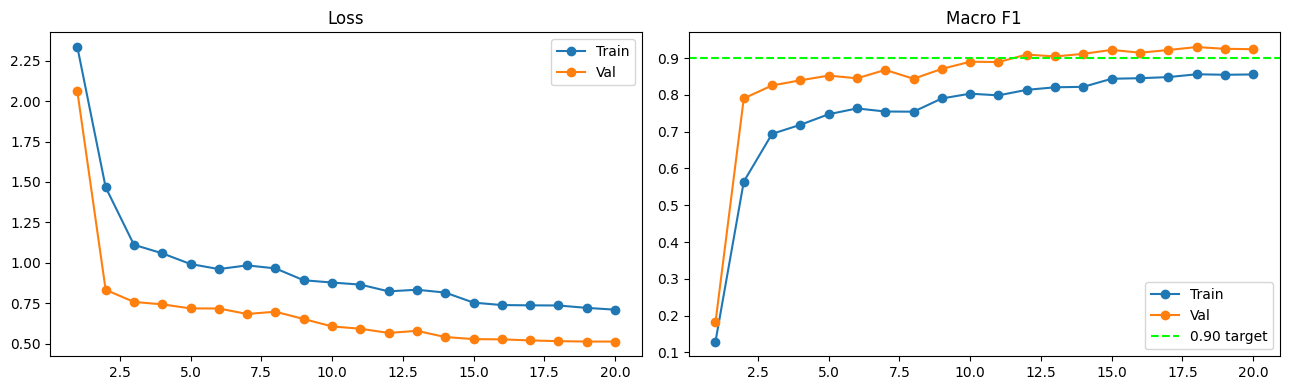

In [14]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist_df.epoch, hist_df.train_loss, 'o-', label='Train')
axes[0].plot(hist_df.epoch, hist_df.val_loss,   'o-', label='Val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(hist_df.epoch, hist_df.train_f1, 'o-', label='Train')
axes[1].plot(hist_df.epoch, hist_df.val_f1,   'o-', label='Val')
axes[1].axhline(0.90, color='lime', ls='--', label='0.90 target')
axes[1].set_title('Macro F1'); axes[1].legend()
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'ast_v3_curves.png'), dpi=120)
plt.show()

---
## 7. Final Evaluation + Per-Class Threshold Optimization

In [15]:
ckpt = torch.load(CHECKPOINT, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

all_probs, all_preds, all_labels = [], [], []
with torch.no_grad():
    for batch in tqdm(val_loader, desc='Final eval'):
        iv  = batch['input_values'].to(DEVICE)
        lbl = batch['labels'].to(DEVICE)
        # Temperature scaling
        probs = torch.softmax(model(input_values=iv).logits / TEMP_SCALE, -1).cpu().numpy()
        all_probs.append(probs)
        all_preds  += probs.argmax(-1).tolist()
        all_labels += lbl.cpu().tolist()

all_probs  = np.vstack(all_probs)
all_labels = np.array(all_labels)

print("=== Val Report (T-scaled argmax) ===")
print(classification_report(all_labels, all_preds, target_names=GENRES, digits=4))

Final eval:   0%|          | 0/113 [00:00<?, ?it/s]

=== Val Report (T-scaled argmax) ===
              precision    recall  f1-score   support

       blues     0.9674    0.9889    0.9780        90
   classical     0.9890    1.0000    0.9945        90
     country     0.9506    0.8556    0.9006        90
       disco     0.9231    0.9333    0.9282        90
      hiphop     0.9011    0.9111    0.9061        90
        jazz     0.9889    0.9889    0.9889        90
       metal     0.9239    0.9444    0.9341        90
         pop     0.9294    0.8778    0.9029        90
      reggae     0.9524    0.8889    0.9195        90
        rock     0.7961    0.9111    0.8497        90

    accuracy                         0.9300       900
   macro avg     0.9322    0.9300    0.9302       900
weighted avg     0.9322    0.9300    0.9302       900



In [16]:
# Per-class threshold search to maximize macro F1 on validation set
from sklearn.metrics import f1_score as sk_f1

thresholds = np.ones(10) * 0.5

print("=== Per-class Threshold Optimization ===")
for cls_idx in range(10):
    best_t, best_f = 0.5, 0.0
    for t in np.arange(0.02, 0.92, 0.02):
        preds_bin  = (all_probs[:, cls_idx] >= t).astype(int)
        labels_bin = (all_labels == cls_idx).astype(int)
        f = sk_f1(preds_bin, labels_bin, zero_division=0)
        if f > best_f:
            best_f, best_t = f, t
    thresholds[cls_idx] = best_t
    print(f'  {GENRES[cls_idx]:12s}: thresh={best_t:.2f}  F1={best_f:.4f}')

# Apply thresholds: highest adjusted margin wins
adj_preds = [int(np.argmax(p - thresholds)) for p in all_probs]
adj_f1    = sk_f1(all_labels, adj_preds, average='macro')
print(f'\n✅ Val F1 (threshold-adjusted): {adj_f1:.4f}')
print(classification_report(all_labels, adj_preds, target_names=GENRES, digits=4))

=== Per-class Threshold Optimization ===
  blues       : thresh=0.30  F1=0.9727
  classical   : thresh=0.38  F1=0.9945
  country     : thresh=0.28  F1=0.8989
  disco       : thresh=0.44  F1=0.9486
  hiphop      : thresh=0.40  F1=0.8989
  jazz        : thresh=0.30  F1=0.9944
  metal       : thresh=0.52  F1=0.9551
  pop         : thresh=0.40  F1=0.9195
  reggae      : thresh=0.32  F1=0.9195
  rock        : thresh=0.32  F1=0.8601

✅ Val F1 (threshold-adjusted): 0.9315
              precision    recall  f1-score   support

       blues     0.9674    0.9889    0.9780        90
   classical     0.9890    1.0000    0.9945        90
     country     0.8977    0.8778    0.8876        90
       disco     0.9651    0.9222    0.9432        90
      hiphop     0.9101    0.9000    0.9050        90
        jazz     0.9889    0.9889    0.9889        90
       metal     0.9551    0.9444    0.9497        90
         pop     0.9294    0.8778    0.9029        90
      reggae     0.9310    0.9000    0.9153

---
## 8. Test Inference — Equal-Weight TTA (7 Clean + 7 Noise) + Temperature Scaling

In [17]:
class TestDataset(Dataset):
    def __init__(self, paths, fe, offset=0.0, noise_pool=None, snr_db=None):
        self.paths      = paths
        self.fe         = fe
        self.offset     = offset
        self.noise_pool = noise_pool or []
        self.snr_db     = snr_db

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        try:
            y, _ = librosa.load(str(self.paths[idx]), sr=SR, mono=True,
                                 duration=CLIP_SEC, offset=self.offset)
            if len(y) < CLIP_SAMPLES:
                y = np.pad(y, (0, CLIP_SAMPLES - len(y)), mode='wrap')
            y = y[:CLIP_SAMPLES]
            if np.max(np.abs(y)) > 0:
                y = y / np.max(np.abs(y))
        except Exception:
            y = np.zeros(CLIP_SAMPLES, dtype=np.float32)

        if self.snr_db is not None and self.noise_pool:
            y = add_noise_snr(y, random.choice(self.noise_pool), self.snr_db)

        return self.fe(y.astype(np.float32), sampling_rate=SR,
                       return_tensors='pt')['input_values'].squeeze(0)

In [18]:
test_df    = pd.read_csv(TEST_CSV)
test_paths = [MASHUP_DIR / Path(row['filename']).name for _, row in test_df.iterrows()]
test_ids   = test_df['id'].tolist()

model.eval()
probs_acc    = np.zeros((len(test_ids), 10), dtype=np.float64)
total_passes = 0


def run_tta(offset, snr_db=None, tag=''):
    global probs_acc, total_passes
    print(f'TTA {tag:8s} | offset={offset}s' + (f' SNR={snr_db}dB' if snr_db else ''))
    ds = TestDataset(test_paths, feature_extractor, offset=offset,
                     noise_pool=noise_pool if snr_db is not None else [],
                     snr_db=snr_db)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=2, pin_memory=True)
    ptr = 0
    with torch.no_grad():
        for batch in tqdm(dl, leave=False):
            probs = torch.softmax(
                model(input_values=batch.to(DEVICE)).logits / TEMP_SCALE, -1
            ).cpu().numpy()
            probs_acc[ptr:ptr+len(probs)] += probs
            ptr += len(probs)
    total_passes += 1


# 7 clean passes
for off in TTA_OFFSETS:
    run_tta(off, tag='Clean')

# 7 noise passes (SNRs chosen to span range seen during training)
noise_snrs = [10, 8, 6, 4, 1, -1, -3]
if noise_pool:
    for snr, off in zip(noise_snrs, TTA_OFFSETS):
        run_tta(off, snr_db=snr, tag='Noise')
else:
    print('⚠️  No noise pool — skipping noise TTA')

probs_acc /= total_passes
print(f'\n✅ Total TTA passes: {total_passes}')

TTA Clean    | offset=0.0s


  0%|          | 0/378 [00:00<?, ?it/s]

TTA Clean    | offset=3.0s


  0%|          | 0/378 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eae4c314c20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eae4c314c20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

TTA Noise    | offset=20.0s SNR=-1dB


  0%|          | 0/378 [00:00<?, ?it/s]

TTA Noise    | offset=25.0s SNR=-3dB


  0%|          | 0/378 [00:00<?, ?it/s]


✅ Total TTA passes: 14


In [19]:
# Primary submission: threshold-adjusted predictions
adj_test  = [ID2GENRE[int(np.argmax(p - thresholds))] for p in probs_acc]
# Backup: plain argmax
argmax_test = [ID2GENRE[i] for i in probs_acc.argmax(axis=1)]

print('\nPrediction distribution (threshold-adjusted):')
pc = Counter(adj_test)
for g in GENRES:
    print(f'  {g:12s}: {pc.get(g,0):5d}  ({100*pc.get(g,0)/len(adj_test):.1f}%)')

print('\nPrediction distribution (argmax):')
pc2 = Counter(argmax_test)
for g in GENRES:
    print(f'  {g:12s}: {pc2.get(g,0):5d}  ({100*pc2.get(g,0)/len(argmax_test):.1f}%)')


Prediction distribution (threshold-adjusted):
  blues       :   321  (10.6%)
  classical   :   229  (7.6%)
  country     :   273  (9.0%)
  disco       :   294  (9.7%)
  hiphop      :   313  (10.4%)
  jazz        :   304  (10.1%)
  metal       :   299  (9.9%)
  pop         :   297  (9.8%)
  reggae      :   333  (11.0%)
  rock        :   357  (11.8%)

Prediction distribution (argmax):
  blues       :   316  (10.5%)
  classical   :   244  (8.1%)
  country     :   258  (8.5%)
  disco       :   306  (10.1%)
  hiphop      :   317  (10.5%)
  jazz        :   299  (9.9%)
  metal       :   312  (10.3%)
  pop         :   309  (10.2%)
  reggae      :   314  (10.4%)
  rock        :   345  (11.4%)


In [20]:
id_col = [str(i).zfill(4) for i in test_ids]

sub_thresh = pd.DataFrame({'id': id_col, 'genre': adj_test})
path_thresh = str(OUT_DIR / 'submission_ast_v3_thresh.csv')
sub_thresh.to_csv(path_thresh, index=False)
print(f'✅ Saved (threshold): {path_thresh}')

sub_argmax = pd.DataFrame({'id': id_col, 'genre': argmax_test})
path_argmax = str(OUT_DIR / 'submission_ast_v3_argmax.csv')
sub_argmax.to_csv(path_argmax, index=False)
print(f'✅ Saved (argmax):    {path_argmax}')

print(sub_thresh.head())

✅ Saved (threshold): /kaggle/working/submission_ast_v3_thresh.csv
✅ Saved (argmax):    /kaggle/working/submission_ast_v3_argmax.csv
     id      genre
0  0001        pop
1  0002  classical
2  0003      disco
3  0004      metal
4  0005    country


In [21]:
per_class = f1_score(all_labels, adj_preds, average=None)
wandb.log({'best_val_macro_f1':   best_val_f1})
wandb.log({'val_f1_thresh_tuned': adj_f1})
wandb.log({f'val_f1_{g}': float(per_class[i]) for i, g in enumerate(GENRES)})
wandb.log({'tta_passes': total_passes})
wandb.log({'thresholds': {g: float(thresholds[i]) for i, g in enumerate(GENRES)}})
wandb.log({'curves': wandb.Image(str(OUT_DIR / 'ast_v3_curves.png'))})
wandb.save(path_thresh)
wandb.save(path_argmax)
wandb.finish()
print('✅ W&B logged!')

wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
wandb: updating run metadata
wandb: uploading history steps 20-25, summary, console lines 117-151
wandb: 
wandb: Run history:
wandb: best_val_macro_f1 ▁
wandb:             epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb:                lr ▅███▇▇▆██▇▇▆▅▄▃▃▂▁▁▁
wandb:          train_f1 ▁▅▆▇▇▇▇▇▇▇▇█████████
wandb:        train_loss █▄▃▃▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁
wandb:        tta_passes ▁
wandb:            val_f1 ▁▇▇▇▇▇▇▇▇███████████
wandb:      val_f1_blues ▁
wandb:  val_f1_classical ▁
wandb:    val_f1_country ▁
wandb:                +9 ...
wandb: 
wandb: Run summary:
wandb: best_val_macro_f1 0.93024
wandb:             epoch 20
wandb:                lr 0.0
wandb:          train_f1 0.85575
wandb:        train_loss 0.71073
wandb:        tta_passes 14
wandb:            val_f1 0.9244
wandb:      val_f1_blues 0.97802
wandb:  val_f1_classical 0.99448

✅ W&B logged!
